In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle, os, warnings
warnings.filterwarnings('ignore')

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier
from sklearn.metrics import (accuracy_score, classification_report,
                             confusion_matrix, roc_auc_score, roc_curve)
from sklearn.model_selection import cross_val_score

print("Libraries loaded")

Libraries loaded


In [2]:
BASE = "../"  # adjust if needed

X_train = pd.read_csv(BASE + "outputs/X_train.csv")
X_test  = pd.read_csv(BASE + "outputs/X_test.csv")
y_train = pd.read_csv(BASE + "outputs/y_train.csv").squeeze()
y_test  = pd.read_csv(BASE + "outputs/y_test.csv").squeeze()

print(f"X_train: {X_train.shape} | X_test: {X_test.shape}")
print(f"y_train distribution:\n{y_train.value_counts()}")

X_train: (763, 42) | X_test: (191, 42)
y_train distribution:
status
1    382
0    381
Name: count, dtype: int64


In [3]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "Random Forest":       RandomForestClassifier(n_estimators=200, random_state=42),
    "Gradient Boosting":   GradientBoostingClassifier(n_estimators=200, random_state=42),
    "SVM":                 SVC(probability=True, kernel='rbf', random_state=42),
    "XGBoost":             XGBClassifier(n_estimators=200, use_label_encoder=False,
                                         eval_metric='logloss', random_state=42)
}
print("5 models defined")

5 models defined


In [4]:
results = {}

for name, model in models.items():
    print(f"\n Training: {name}")
    model.fit(X_train, y_train)
    
    y_pred  = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]
    
    acc    = accuracy_score(y_test, y_pred)
    auc    = roc_auc_score(y_test, y_proba)
    cv_acc = cross_val_score(model, X_train, y_train, cv=5, scoring='accuracy').mean()
    
    results[name] = {"Accuracy": acc, "ROC-AUC": auc, "CV Accuracy": cv_acc,
                     "model": model, "y_pred": y_pred, "y_proba": y_proba}
    print(f"  Accuracy: {acc:.4f} | AUC: {auc:.4f} | CV: {cv_acc:.4f}")

print("\n All models trained!")


 Training: Logistic Regression
  Accuracy: 0.7173 | AUC: 0.8124 | CV: 0.7104

 Training: Random Forest
  Accuracy: 0.8115 | AUC: 0.9089 | CV: 0.7916

 Training: Gradient Boosting
  Accuracy: 0.8115 | AUC: 0.9005 | CV: 0.7733

 Training: SVM
  Accuracy: 0.7435 | AUC: 0.8441 | CV: 0.7405

 Training: XGBoost
  Accuracy: 0.7749 | AUC: 0.8817 | CV: 0.7707

 All models trained!


In [5]:
summary = pd.DataFrame({
    name: {"Accuracy": v["Accuracy"], "ROC-AUC": v["ROC-AUC"], "CV Accuracy": v["CV Accuracy"]}
    for name, v in results.items()
}).T.sort_values("ROC-AUC", ascending=False)

print(summary.to_string())

os.makedirs("../outputs", exist_ok=True)
summary.to_csv("../outputs/ml_model_comparison.csv")
print("\n Saved to outputs/ml_model_comparison.csv")

                     Accuracy   ROC-AUC  CV Accuracy
Random Forest        0.811518  0.908882     0.791649
Gradient Boosting    0.811518  0.900548     0.773271
XGBoost              0.774869  0.881689     0.770657
SVM                  0.743455  0.844079     0.740497
Logistic Regression  0.717277  0.812390     0.710397

 Saved to outputs/ml_model_comparison.csv


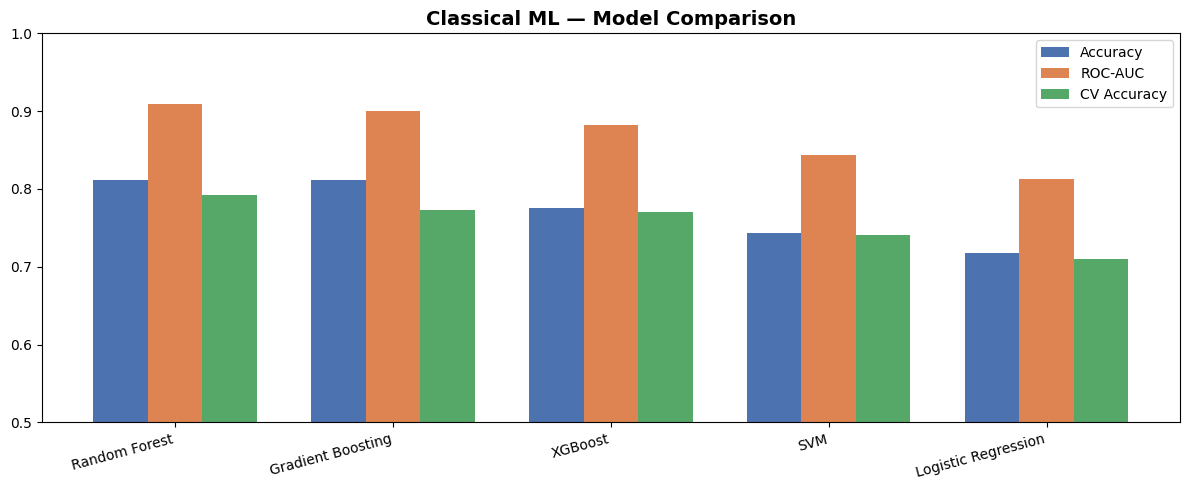

 Saved plot 12


In [6]:
os.makedirs("../outputs/plots", exist_ok=True)

fig, ax = plt.subplots(figsize=(12, 5))
x = np.arange(len(summary))
width = 0.25

ax.bar(x - width, summary["Accuracy"],   width, label="Accuracy",    color="#4C72B0")
ax.bar(x,          summary["ROC-AUC"],   width, label="ROC-AUC",     color="#DD8452")
ax.bar(x + width,  summary["CV Accuracy"], width, label="CV Accuracy", color="#55A868")

ax.set_xticks(x)
ax.set_xticklabels(summary.index, rotation=15, ha='right')
ax.set_ylim(0.5, 1.0)
ax.set_title("Classical ML — Model Comparison", fontsize=14, fontweight='bold')
ax.legend()
plt.tight_layout()
plt.savefig("../outputs/plots/12_model_comparison.png", dpi=150)
plt.show()
print(" Saved plot 12")

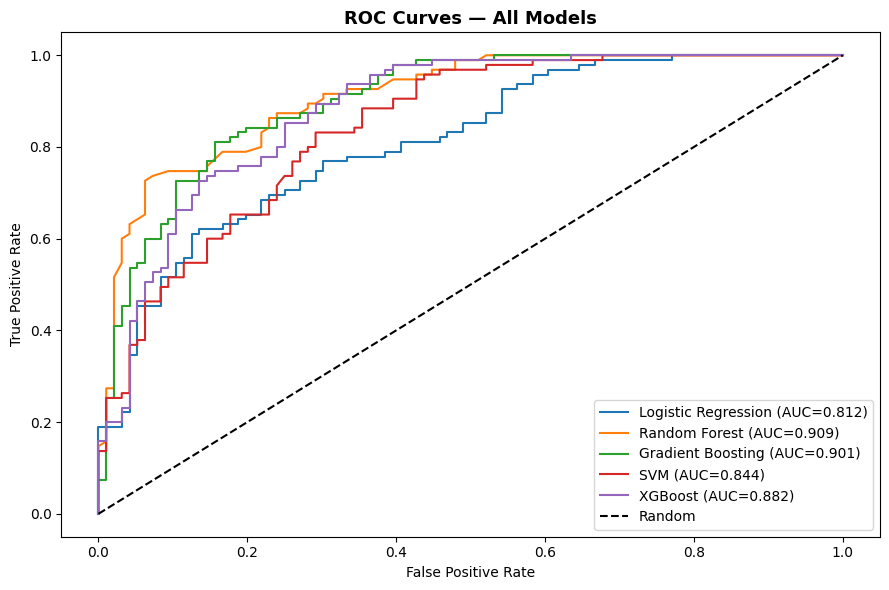

 Saved plot 13


In [7]:
fig, ax = plt.subplots(figsize=(9, 6))

for name, v in results.items():
    fpr, tpr, _ = roc_curve(y_test, v["y_proba"])
    ax.plot(fpr, tpr, label=f"{name} (AUC={v['ROC-AUC']:.3f})")

ax.plot([0,1],[0,1],'k--', label="Random")
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.set_title("ROC Curves — All Models", fontsize=13, fontweight='bold')
ax.legend(loc='lower right')
plt.tight_layout()
plt.savefig("../outputs/plots/13_roc_curves.png", dpi=150)
plt.show()
print(" Saved plot 13")

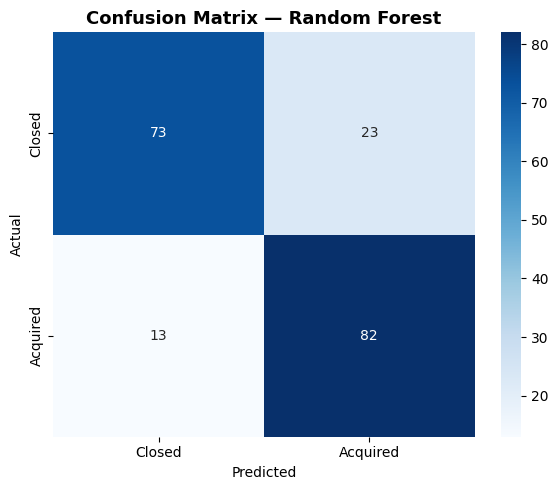


 Classification Report — Random Forest:
              precision    recall  f1-score   support

      Closed       0.85      0.76      0.80        96
    Acquired       0.78      0.86      0.82        95

    accuracy                           0.81       191
   macro avg       0.81      0.81      0.81       191
weighted avg       0.82      0.81      0.81       191



In [8]:
best_name = summary.index[0]
best = results[best_name]

cm = confusion_matrix(y_test, best["y_pred"])
fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=["Closed","Acquired"], yticklabels=["Closed","Acquired"], ax=ax)
ax.set_title(f"Confusion Matrix — {best_name}", fontsize=13, fontweight='bold')
ax.set_ylabel("Actual"); ax.set_xlabel("Predicted")
plt.tight_layout()
plt.savefig("../outputs/plots/14_confusion_matrix.png", dpi=150)
plt.show()
print(f"\n Classification Report — {best_name}:")
print(classification_report(y_test, best["y_pred"], target_names=["Closed","Acquired"]))

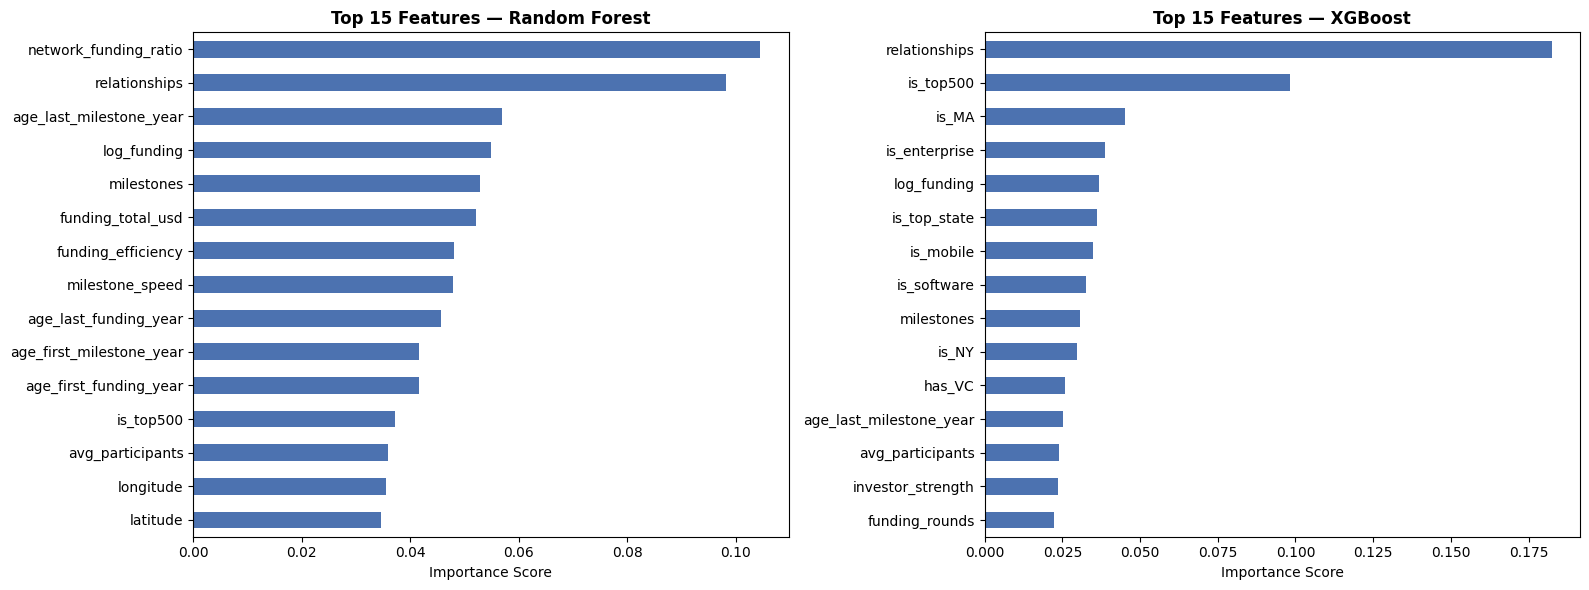

 Saved plot 15


In [9]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax, model_name in zip(axes, ["Random Forest", "XGBoost"]):
    model = results[model_name]["model"]
    importances = pd.Series(model.feature_importances_, index=X_train.columns)
    top15 = importances.nlargest(15).sort_values()
    top15.plot(kind='barh', ax=ax, color="#4C72B0")
    ax.set_title(f"Top 15 Features — {model_name}", fontweight='bold')
    ax.set_xlabel("Importance Score")

plt.tight_layout()
plt.savefig("../outputs/plots/15_feature_importance.png", dpi=150)
plt.show()
print(" Saved plot 15")

In [10]:
os.makedirs("../models", exist_ok=True)

best_model = results[best_name]["model"]
with open(f"../models/best_classical_model.pkl", "wb") as f:
    pickle.dump(best_model, f)

with open(f"../models/best_model_name.txt", "w") as f:
    f.write(best_name)

print(f" Best model saved: {best_name}")
print(f"  Accuracy : {best['Accuracy']:.4f}")
print(f"  ROC-AUC  : {best['ROC-AUC']:.4f}")
print(f"  CV Score : {best['CV Accuracy']:.4f}")

 Best model saved: Random Forest
  Accuracy : 0.8115
  ROC-AUC  : 0.9089
  CV Score : 0.7916
